In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
medical=pd.read_csv('C:\\Users\\hp\\Downloads\\insurance.csv')
medical.head(23)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
medical.shape

(1338, 7)

In [3]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
medical.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
def plot_hist(df:pd.DataFrame,col:str):
    plt.figure()
    df[col].hist(bins=20)
    plt.title(f'distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

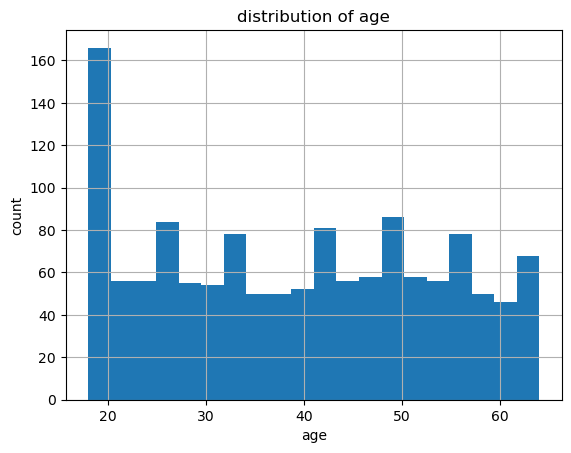

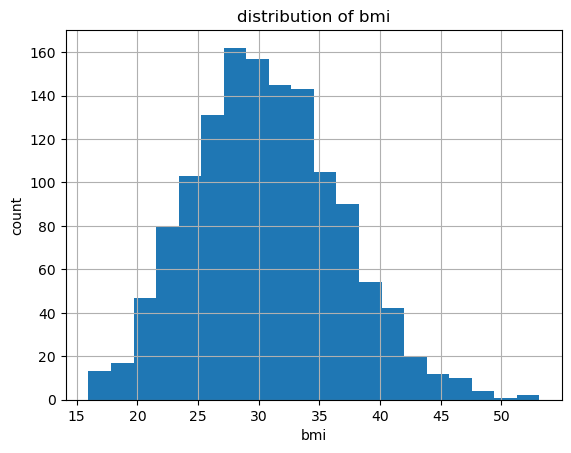

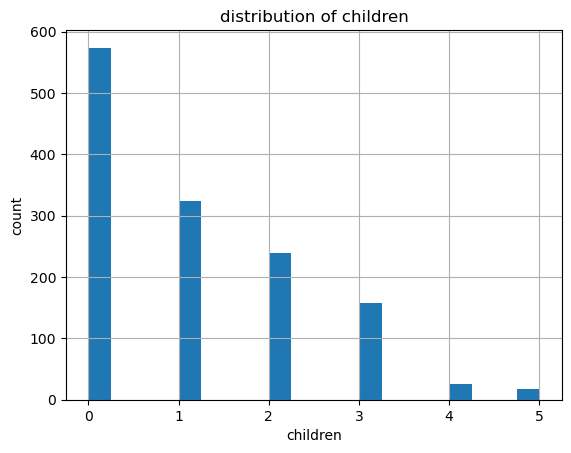

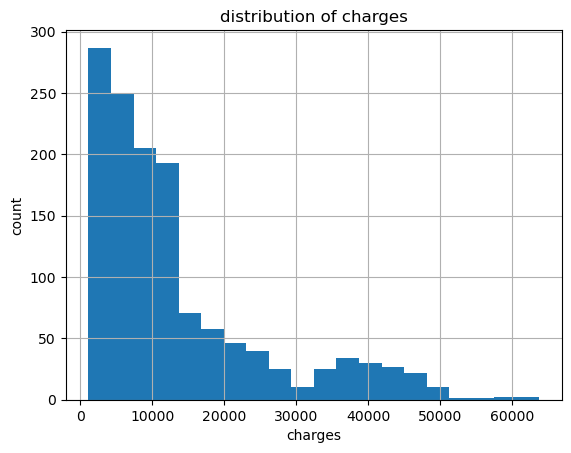

In [6]:
for col in ['age','bmi','children','charges']:
    plot_hist(medical,col)

In [7]:
def plot_cat(df: pd.DataFrame,col:str):
    plt.figure()
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'counts by {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

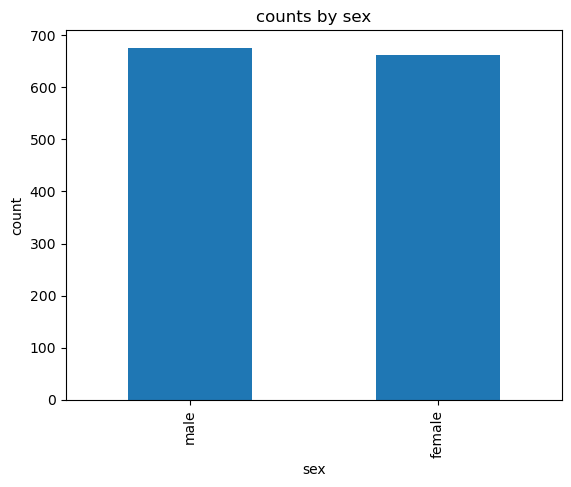

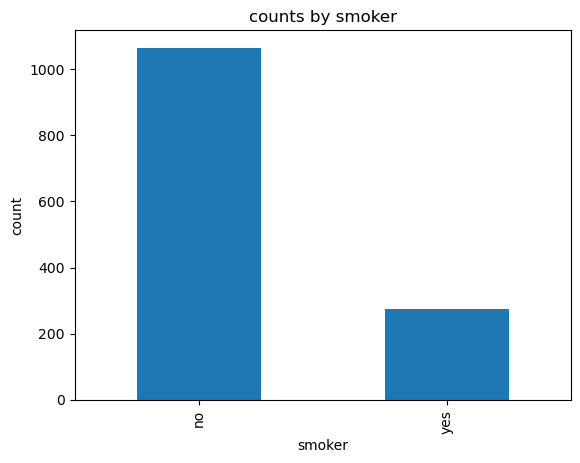

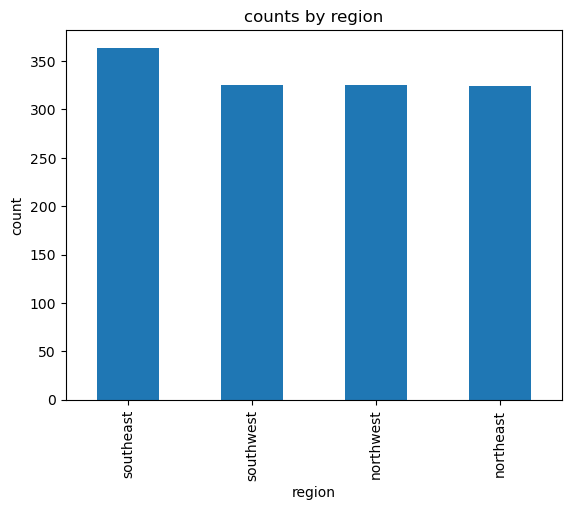

In [8]:
for col in ['sex','smoker','region']:
    plot_cat(medical,col)

In [9]:
def plot_scatter(df: pd.DataFrame, xcol: str, ycol: str):
    plt.figure()
    plt.scatter(df[xcol], df[ycol])
    plt.title(f"{xcol} vs {ycol}")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.tight_layout()
    plt.show()

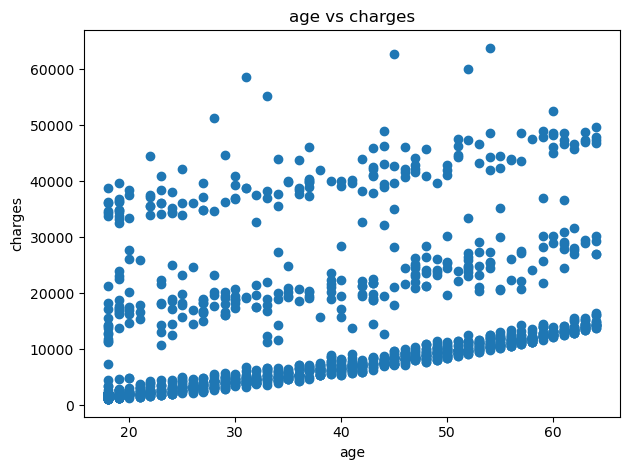

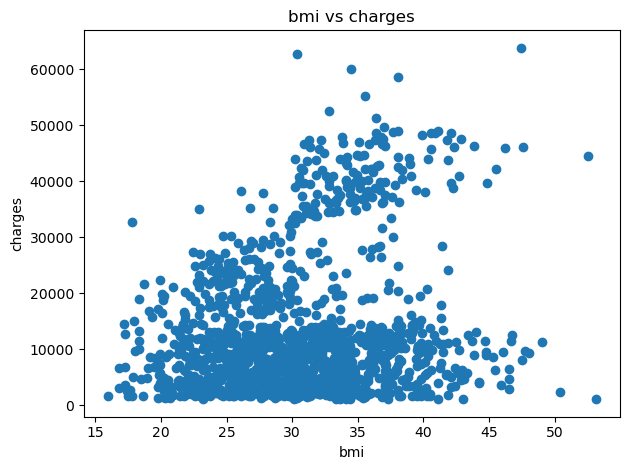

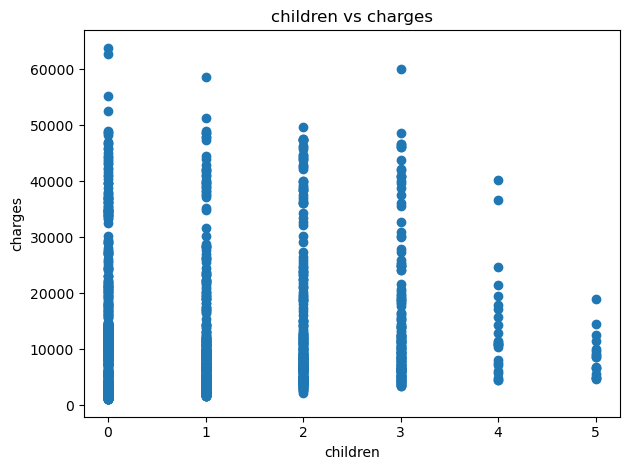

In [10]:
for x in ["age", "bmi", "children"]:
    plot_scatter(medical, x, "charges")

In [11]:
def plot_box_by_group(df: pd.DataFrame, value_col: str, group_col: str):
    plt.figure()
    groups = df.groupby(group_col)[value_col].apply(list)
    positions = range(1, len(groups) + 1)
    plt.boxplot(groups.tolist(), positions=list(positions), labels=list(groups.index))
    plt.title(f"{value_col} by {group_col}")
    plt.xlabel(group_col)
    plt.ylabel(value_col)
    plt.tight_layout()
    plt.show()

In [16]:
medical['sex']=medical['sex'].map({'female':0,'male':1})
medical['smoker']=medical['smoker'].map({'no':0,'yes':1})
medical['region']=medical['region'].map({'southeast':1,'southwest':2,'northwest':3,'northeast':4})

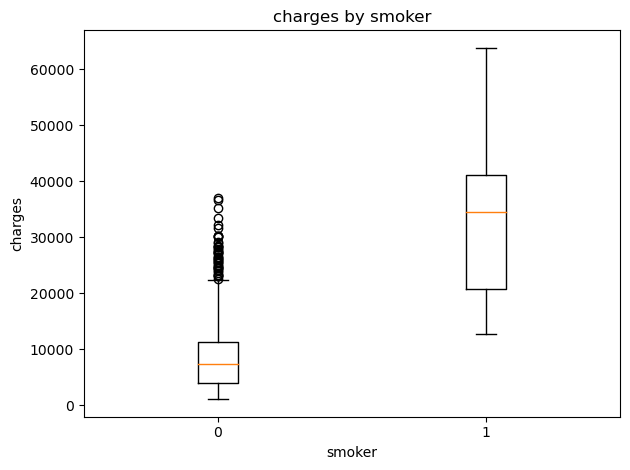

In [17]:
plot_box_by_group(medical, "charges", "smoker")

In [13]:
def plot_corr_heatmap(df: pd.DataFrame, numeric_cols: list[str]):
    corr = df[numeric_cols].corr()
    plt.figure()
    plt.imshow(corr, interpolation='nearest')
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
    plt.yticks(range(len(numeric_cols)), numeric_cols)
    plt.title("Correlation heatmap (numeric)")
    for (i, j) in itertools.product(range(len(numeric_cols)), range(len(numeric_cols))):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

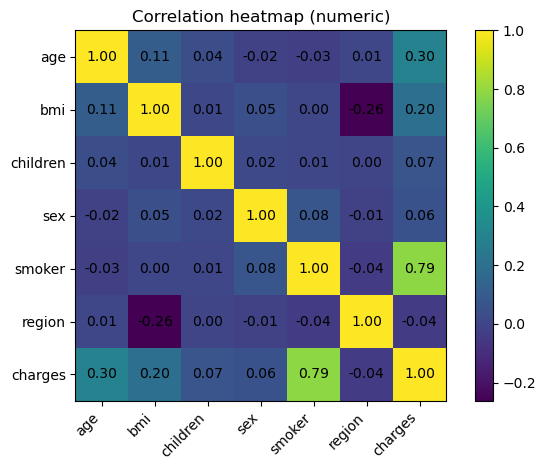

In [19]:
import itertools
plot_corr_heatmap(medical, ["age", "bmi", "children", "sex","smoker",'region','charges'])

In [23]:
from itertools import combinations
target = "charges"
features = ["age","bmi","children","sex","smoker","region"]
interaction_results = {}
for f1, f2 in combinations(features, 2):
    new_feature = medical[f1] * medical[f2]
    corr = new_feature.corr(medical[target])
    interaction_results[f"{f1}*{f2}"] = corr

interaction_df = pd.DataFrame.from_dict(interaction_results, orient='index', columns=['correlation'])
interaction_df = interaction_df.sort_values(by="correlation", ascending=False)

print(interaction_df)

                 correlation
bmi*smoker          0.845120
age*smoker          0.789253
smoker*region       0.649251
sex*smoker          0.599792
children*smoker     0.524875
age*bmi             0.334754
age*sex             0.149049
age*region          0.140981
age*children        0.131964
bmi*children        0.102592
bmi*sex             0.101780
children*sex        0.078688
children*region     0.051046
bmi*region          0.043453
sex*region          0.020153


In [24]:
results = []

for r in range(1, len(features)+1):

    combos = itertools.combinations(features, r)

    for combo in combos:

        combo = list(combo)

        # combine features (mean normalization)
        combined = medical[combo].mean(axis=1)

        corr = combined.corr(medical[target])

        results.append({
            "features": combo,
            "num_features": r,
            "correlation_with_charges": corr
        })

results_df = pd.DataFrame(results)

print(results_df.sort_values("correlation_with_charges", ascending=False))

                                     features  num_features  \
4                                    [smoker]             1   
18                              [sex, smoker]             2   
56          [age, bmi, children, sex, smoker]             5   
62  [age, bmi, children, sex, smoker, region]             6   
42               [age, bmi, children, smoker]             4   
..                                        ...           ...   
3                                       [sex]             1   
38                    [children, sex, region]             3   
17                         [children, region]             2   
19                              [sex, region]             2   
5                                    [region]             1   

    correlation_with_charges  
4                   0.787251  
18                  0.520018  
56                  0.364518  
62                  0.363288  
42                  0.362936  
..                       ...  
3                   0.0572

In [26]:
import pandas as pd
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

target = "charges"

features = ["age","bmi","children","sex","smoker","region"]

def multiple_corr(df, feature_list, target):
    
    X = medical[feature_list]
    y = medical[target]
    
    model = LinearRegression()
    model.fit(X,y)
    
    y_pred = model.predict(X)
    
    corr = np.corrcoef(y, y_pred)[0,1]
    
    return corr

In [29]:
def compute_combination_corr(medical, features, target, k):

    results = []

    combos = list(itertools.combinations(features, k))

    for combo in combos:

        corr = multiple_corr(medical, list(combo), target)

        results.append({
            "features": ", ".join(combo),
            "correlation": corr
        })

    return pd.DataFrame(results)

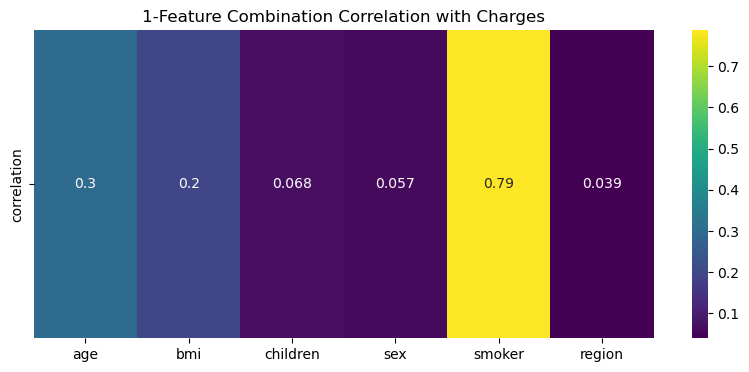

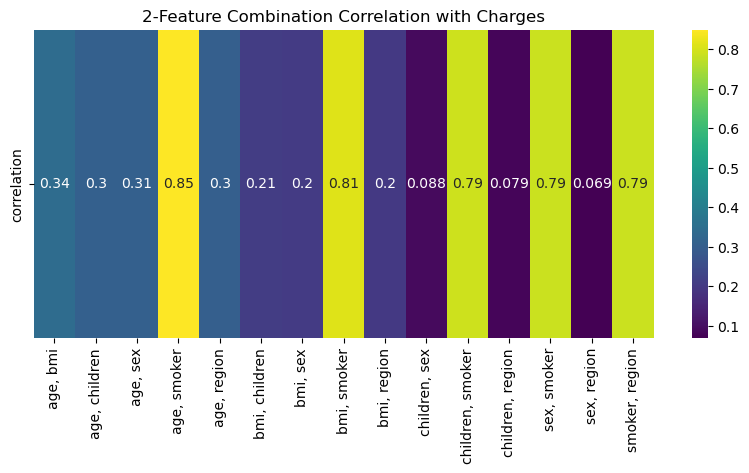

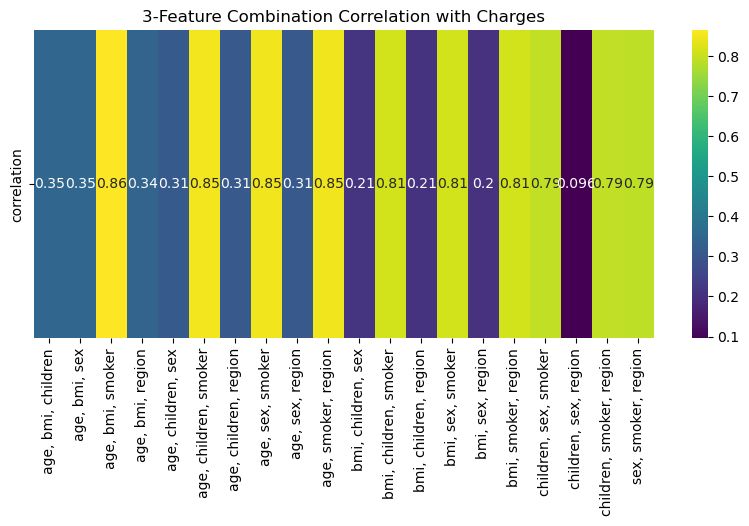

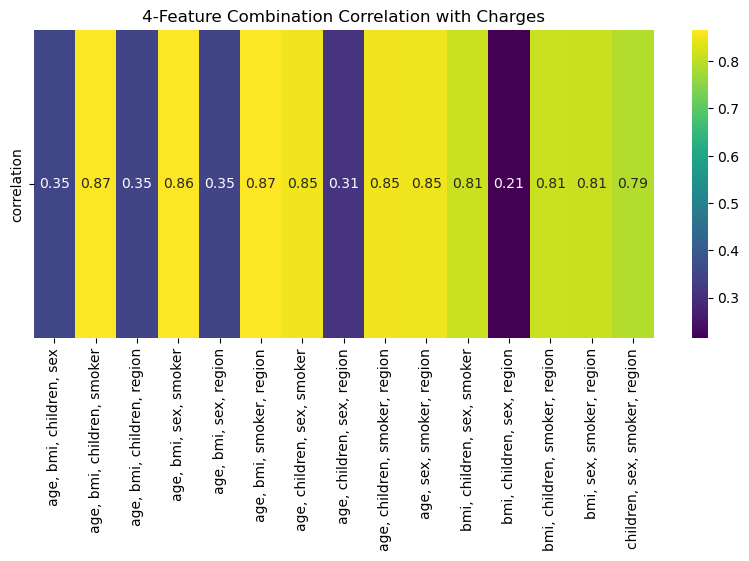

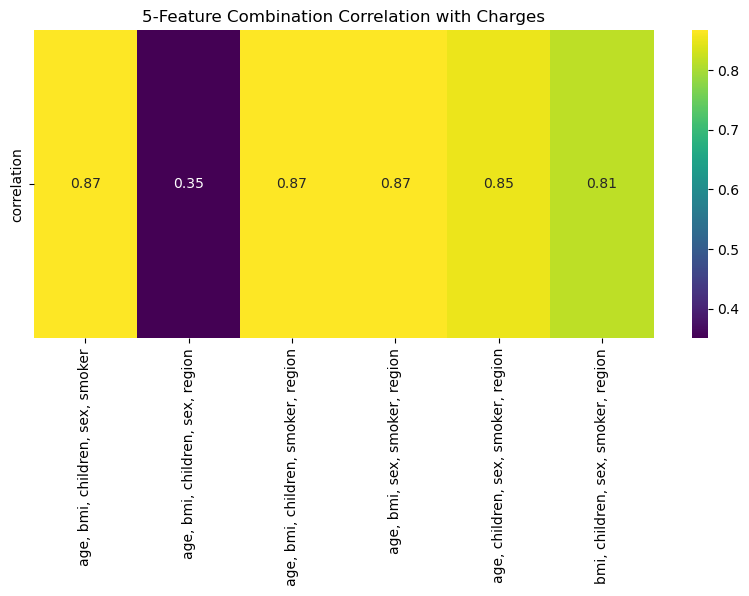

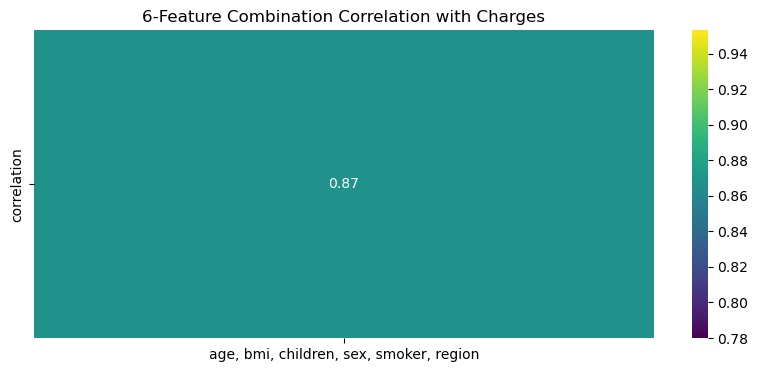

In [30]:
for k in range(1, len(features)+1):

    df_corr = compute_combination_corr(medical, features, "charges", k)

    plt.figure(figsize=(10,4))

    sns.heatmap(
        df_corr[["correlation"]].T,
        annot=True,
        cmap="viridis",
        xticklabels=df_corr["features"]
    )

    plt.title(f"{k}-Feature Combination Correlation with Charges")
    plt.show()